# 여행 유형 분석 — 최종 정리 (발표용)

`clustering.ipynb`(v1) → `clustering_v2.ipynb`(v2)를 거치며 제기된 질문들과, 그 질문에
**답하기 위해 실제로 돌린 검증**을 한 파일에 모았다. 이 노트북만 보면 결론과 근거가 모두 재현된다.

---

## 우리가 던진 질문

| | 질문 | 어디서 나왔나 |
|---|---|---|
| **Q1** | 클러스터링으로 여행 유형 **군집**을 찾을 수 있는가? | v1 전체. v1 §12에서 *"두 그룹 사이에 gap이 없다"* 고 인정하며 미해결로 남음 |
| **Q2** | 축은 몇 개가 좋은가? 2컬럼 조합 여러 개 vs 컬럼 하나씩 x·y·z | v1(2컬럼 KMeans) vs v2(1컬럼 분위수) 방식 차이 |
| **Q3** | **서로 독립인 컬럼이 아주 많다. 그중 무엇을 기준으로 고르는가?** | v2 §2-1. *"게이트 통과 22개 중 최종 3축 낙점은 설계 결정"* 이라고 인정하며 미해결로 남음 |
| **Q4** | 자기보고(`TRAVEL_MISSION`, `TRAVEL_STYL_1~8`)로 검증하면 되지 않나? | Q3를 풀려고 시도했으나 PCA·AE로도 안 나뉨 |
| **Q5** | 최적동선 지표 `ratio`는 축으로 쓸 수 있는가? | v1이 축A의 핵심 재료로 사용 |

## 답 요약

| | 답 |
|---|---|
| **A1** | **군집은 없다.** 귀무분포 대비 gap ≈ 0. 게다가 v1에서 군집처럼 보였던 것은 전부 **함수적 종속·점질량 아티팩트**였다 (§2) |
| **A2** | **컬럼 하나 = 축 하나**가 맞다. 독립 2컬럼 KMeans는 임의 방향으로 자르는 것이라 1컬럼 분위수 절단보다 나은 점이 없다 (§3) |
| **A3** | **독립성만으로는 못 고른다.** 독립성은 게이트로만 쓰고, **② 설명력**과 **③ 성향성**을 추가해야 순위가 갈린다 (§4~§6) |
| **A4** | **자기보고는 정답지가 아니다.** 22개 조합 전부와 무관(V<0.1)했다. 이건 실패가 아니라 결과(say-do gap)다 (§7) |
| **A5** | **쓸 수 없다.** `ratio`는 사실상 방문지 개수의 단조함수다. 그 효과를 제거하면 남는 신호가 없다 (§8) |

**최종 산출**: 3축 8유형 좌표계 (§6)

---
## 1. 데이터 로드 및 파생 컬럼

In [1]:
import pandas as pd, numpy as np, itertools, warnings
warnings.filterwarnings('ignore')
from scipy.stats import spearmanr, rankdata
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
plt.rcParams['axes.unicode_minus'] = False   # 그림 라벨은 ASCII 사용 (한글 폰트 비의존)

RAW = pd.read_csv('../data/travel_efficiency_index.csv')
df = RAW[RAW['n_middle_visits'] >= 3].copy()                                        # v1/v2와 동일 필터
df = df[df['spend_income_ratio'] < df['spend_income_ratio'].quantile(0.99)].copy()

CAT = [c for c in df.columns if c.startswith('category_share_')]
DWL = [c for c in df.columns if c.startswith('dwell_share_')]
eps = 1e-12
Cm = df[CAT].fillna(0).values; Cm = Cm/np.clip(Cm.sum(1, keepdims=True), eps, None)
Dm = df[DWL].fillna(0).values; Dm = Dm/np.clip(Dm.sum(1, keepdims=True), eps, None)
Mm = (Cm+Dm)/2

# ── 이번 분석에서 새로 만든 컬럼 5종 ──
df['visit_dwell_gap']  = (0.5*np.nansum(np.where(Cm>0, Cm*np.log2(Cm/np.clip(Mm,eps,None)), 0), 1)
                        + 0.5*np.nansum(np.where(Dm>0, Dm*np.log2(Dm/np.clip(Mm,eps,None)), 0), 1))  # JS divergence, 밑 2 → [0,1] 유계
df['dwell_entropy']    = -(np.where(Dm>0, Dm*np.log(np.clip(Dm,eps,None)), 0)).sum(1)   # ln (category_entropy와 동일 밑)
df['dwell_top1']       = Dm.max(1)
df['spend_per_visit']  = df.total_spend_won/df.n_tourism_visits.clip(lower=1)
df['mainstream_share'] = df[['category_share_11','category_share_1']].fillna(0).sum(1)

POOL = ['ratio','spend_income_ratio','motive_purpose_ratio','category_entropy','avg_daily_poi_visits',
        'revisit_ratio','mode_diversity','trip_days','per_person_spend_won',
        'visit_dwell_gap','dwell_entropy','dwell_top1','spend_per_visit','mainstream_share']
KR = {'ratio':'효율성(최적동선)','spend_income_ratio':'소비/소득','motive_purpose_ratio':'목적형동기',
      'category_entropy':'방문다양성','avg_daily_poi_visits':'방문밀도','revisit_ratio':'재방문',
      'mode_diversity':'이동수단다양','trip_days':'여행일수','per_person_spend_won':'1인지출',
      'visit_dwell_gap':'방문↔체류불일치','dwell_entropy':'체류다양성','dwell_top1':'체류쏠림',
      'spend_per_visit':'장소당지출','mainstream_share':'주류코스비중'}
NEWCOLS = ['visit_dwell_gap','dwell_entropy','dwell_top1','spend_per_visit','mainstream_share']

d = df.dropna(subset=POOL).reset_index(drop=True); n = len(d)
print(f'원본 {len(RAW)}행 → 필터 후 {len(df)}행 → 축 후보 결측 제거 후 분석표본 n = {n}')
print(f'travel_id 고유 {d.travel_id.nunique()} / traveler_id 고유 {d.traveler_id.nunique()}  (1인 1여행)')
print(f'\n신규 파생 컬럼 {len(NEWCOLS)}종: ' + ', '.join(KR[c] for c in NEWCOLS))

원본 10028행 → 필터 후 5378행 → 축 후보 결측 제거 후 분석표본 n = 5376
travel_id 고유 5376 / traveler_id 고유 5376  (1인 1여행)

신규 파생 컬럼 5종: 방문↔체류불일치, 체류다양성, 체류쏠림, 장소당지출, 주류코스비중


### 1-1. 신규 파생 컬럼 5종 — 어떻게 만들었나

기존 61개 컬럼에 없는 정보를 담기 위해 새로 만든 컬럼이다. 위 셀의 코드가 그대로 정의다.

**`visit_dwell_gap` — 방문↔체류 불일치**
`C` = 방문 **횟수** 기준 카테고리 구성비(13차원), `D` = 체류 **시간** 기준 구성비(13차원).
두 분포의 **Jensen-Shannon divergence**(밑 2 → 값이 [0,1]로 유계):

$$\mathrm{JS}(C,D)=\tfrac12 \mathrm{KL}(C\Vert M)+\tfrac12 \mathrm{KL}(D\Vert M),\qquad M=\tfrac{C+D}{2}$$

- **0에 가까움** = 많이 들른 곳과 오래 있은 곳이 일치
- **크면** = 들르기는 여러 곳 들렀는데 시간은 딴 데 썼다
- KL 대신 JS를 쓴 이유: 대칭이고, 한쪽이 0인 카테고리에서 발산하지 않으며, 유계라 절단점 해석이 안정적이다.
- **기존 어떤 컬럼도 이 정보를 담고 있지 않다** — `category_entropy`는 횟수만, `dwell_share`는 시간만 본다.

**`dwell_entropy` — 체류 다양성**  `-Σ D_k ln D_k` (자연로그. `category_entropy`와 밑을 맞췄다)
기존 `category_entropy`가 **방문 횟수** 기준인 것에 대응하는 **체류 시간** 기준 버전.

**`dwell_top1` — 체류 쏠림**  `max(D)`. 가장 오래 머문 카테고리 하나가 차지한 시간 비중.

**`spend_per_visit` — 장소당 지출**  `total_spend_won / max(n_tourism_visits, 1)`
기존 `per_person_spend_won`(= 사람당)과 분모가 다르다. "몇 곳에 나눠 썼는가"를 본다.

**`mainstream_share` — 주류 코스 비중**  `category_share_11 + category_share_1` (식당카페 + 자연)
v1 §3은 희소 카테고리를 **개별로** 클러스터링하려다 "그 활동을 조금이라도 한 소수"만 쪼개는 실패를 겪었다.
여기서는 **가장 흔한 두 카테고리를 묶어 주류/비주류 한 축으로 만들어** 희소성 문제를 우회한다.

### 1-2. 기존 컬럼은 어떻게 만들어졌나 — 계산식 역검증

`travel_efficiency_index.csv`를 생성한 스크립트는 이 폴더에 없다. 그래서 **추측하지 않고,
데이터로 계산식을 역검증**했다. 아래 셀은 후보 수식을 실제로 계산해 일치율을 출력한다.

In [2]:
def verify(name, a, b):
    a = np.asarray(a, float); b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    r = np.isclose(a[m], b[m], rtol=1e-4, atol=1e-9).mean() if m.sum() else np.nan
    print(f'  {name:56s} 일치율 {r:6.1%}   (n={m.sum()})')

R_ = RAW
S_ = R_[CAT].fillna(0).values
print('▶ 조성(구성비) 컬럼')
verify('category_share_* 합계 == 1', R_[CAT].sum(1), np.ones(len(R_)))
verify('dwell_share_* 합계 == 1',    R_[DWL].sum(1), np.ones(len(R_)))
verify('motive_* 4종 합계 == 1',
       R_[['motive_purpose_ratio','motive_convenience_ratio',
           'motive_revisit_reason_ratio','motive_other_ratio']].sum(1), np.ones(len(R_)))

print('\n▶ 엔트로피 — 로그의 밑 확인')
verify('category_entropy == -Σ p·log2(p)', R_.category_entropy,
       -(np.where(S_>0, S_*np.log2(np.clip(S_,1e-12,None)), 0)).sum(1))
verify('category_entropy == -Σ p·ln(p)   ', R_.category_entropy,
       -(np.where(S_>0, S_*np.log(np.clip(S_,1e-12,None)),  0)).sum(1))

print('\n▶ 지출 컬럼')
verify('per_person_spend_won == total_spend/(동반인원+1)', R_.per_person_spend_won,
       R_.total_spend_won/(R_.TRAVEL_COMPANIONS_NUM+1))
verify('spend_income_ratio == total_spend/income_won',      R_.spend_income_ratio,
       R_.total_spend_won/R_.income_won)
verify('spend_income_ratio == per_person_spend/income_won', R_.spend_income_ratio,
       R_.per_person_spend_won/R_.income_won)
verify('spend_house_income_ratio == per_person/house_income', R_.spend_house_income_ratio,
       R_.per_person_spend_won/R_.house_income_won)

print('\n▶ 동선 컬럼')
print(f'  n_coord_visits - n_middle_visits 분포: {dict(list((R_.n_coord_visits-R_.n_middle_visits).value_counts().items())[:3])}')
print('  → 좌표 방문지에서 출발·도착 2개를 뺀 것이 middle. ratio는 그 중간지점들의 순회 최적화 비율이다.')

print('\n▶ 밀도 컬럼 (완전히 일치하는 수식을 못 찾음 — 정직하게 남김)')
verify('avg_daily_poi_visits == n_tourism/trip_days',     R_.avg_daily_poi_visits, R_.n_tourism_visits/R_.trip_days)
verify('avg_daily_poi_visits == n_tourism/(trip_days-1)', R_.avg_daily_poi_visits,
       R_.n_tourism_visits/(R_.trip_days-1).clip(lower=1))

print('\n▶ 소득은 구간 대푯값이다 (연속형이 아님)')
print('  INCOME 코드:', sorted(R_.INCOME.dropna().unique())[:10])
print('  income_won 값:', sorted(R_.income_won.dropna().unique())[:8], '... (구간 중앙값)')

▶ 조성(구성비) 컬럼
  category_share_* 합계 == 1                                 일치율 100.0%   (n=10028)
  dwell_share_* 합계 == 1                                    일치율 100.0%   (n=10028)
  motive_* 4종 합계 == 1                                      일치율 100.0%   (n=10028)

▶ 엔트로피 — 로그의 밑 확인
  category_entropy == -Σ p·log2(p)                         일치율   3.4%   (n=10028)
  category_entropy == -Σ p·ln(p)                           일치율 100.0%   (n=10028)

▶ 지출 컬럼
  per_person_spend_won == total_spend/(동반인원+1)             일치율 100.0%   (n=10025)
  spend_income_ratio == total_spend/income_won             일치율  19.4%   (n=8718)
  spend_income_ratio == per_person_spend/income_won        일치율 100.0%   (n=8718)
  spend_house_income_ratio == per_person/house_income      일치율 100.0%   (n=7668)

▶ 동선 컬럼
  n_coord_visits - n_middle_visits 분포: {2: 9721, 1: 307}
  → 좌표 방문지에서 출발·도착 2개를 뺀 것이 middle. ratio는 그 중간지점들의 순회 최적화 비율이다.

▶ 밀도 컬럼 (완전히 일치하는 수식을 못 찾음 — 정직하게 남김)
  avg_daily_poi_visits == n_tourism/trip_days         

### 역검증 결과 — 컬럼 사전

| 컬럼 | 확정된 계산식 | 확인 |
|---|---|---|
| `category_share_k` | 카테고리 k 방문 횟수 / 전체 관광 방문 횟수 (합 = 1) | ✅ 100% |
| `dwell_share_k` | 카테고리 k **체류시간** / 전체 체류시간 (합 = 1) | ✅ 100% |
| `motive_*_ratio` | 방문 동기 4종의 비율 (합 = 1) | ✅ 100% |
| `category_entropy` | `-Σ p·ln(p)` — **자연로그** (log2 아님) | ✅ 100% |
| `per_person_spend_won` | `total_spend_won / (TRAVEL_COMPANIONS_NUM + 1)` | ✅ 100% |
| `spend_income_ratio` | **`per_person_spend_won / income_won`** (총지출 아님) | ✅ 100% |
| `spend_house_income_ratio` | `per_person_spend_won / house_income_won` | ✅ 100% |
| `n_coord_visits` | `n_middle_visits + 2` (출발·도착 포함) | ✅ 97% |
| `ratio` | 실제 동선 길이 / 중간지점 순회 최적 동선 길이 (§8 참조) | ✅ 최소 1.0, 미만 0건 |
| `mode_diversity` | 사용한 이동수단 종류 수 (정수 1~10) | ✅ |
| `avg_daily_poi_visits` | 방문수/일수 계열이나 **정확한 분모 미확정** | ⚠️ 94% |
| `efficiency_level`·`density_level`·`quadrant` | 사전 계산된 라벨(효율적/비효율적 × 여유/알참) — 이 분석에서는 미사용 | — |

**여기서 나온 두 가지 중요한 사실:**

1. **`spend_income_ratio`의 분자는 총지출이 아니라 1인당 지출이고, 분모 `income_won`은 구간 대푯값이다.**
   `INCOME` 코드 1~10을 50만·150만·250만… 으로 펼친 값이라 **실질적으로 8~10단계 순서형**이다.
   §4-3에서 이 축의 상황R²가 0.656으로 나온 것 — 즉 "소비 축이 사실상 소득 축"인 것과 일관된다.
2. **`avg_daily_poi_visits`는 계산식을 100% 재현하지 못했다.** 이 분석에서는 축으로 채택되지 않아
   결론에 영향이 없지만, 쓸 일이 생기면 원본 생성 스크립트를 확인해야 한다.

---
## 2. Q1 — 군집은 존재하는가? (정면 검증)

v1 §2-1은 *"정규분포 가짜 데이터도 1D 실루엣 0.56이 나온다"* 로 **1차원** 실루엣이 못 믿을 값임을 보였다.
그런데 정작 축을 결정한 **2차원** 실루엣에는 같은 검증을 하지 않았다. 여기서 그 누락을 메운다.

**귀무데이터 설계**: 각 컬럼을 **독립적으로 셔플**한다.
왜도·이산성·0비율 등 주변분포는 100% 보존되고 **결합 구조만 파괴**되므로,
"군집이 전혀 없지만 생김새는 똑같은 데이터"가 된다. 관측값이 이보다 뚜렷이 좋아야 군집이 있다고 말할 수 있다.

gap = log(귀무 관성) − log(관측 관성). 군집이 있으면 양수로 크게 나온다.

In [3]:
def logW(X, k):
    km = KMeans(k, n_init=5, random_state=0).fit(X)
    return np.log(km.inertia_), km.labels_

def null_refs(X, nref=10):
    return [StandardScaler().fit_transform(
              np.column_stack([np.random.default_rng(1000+r*17+j).permutation(X[:, j])
                               for j in range(X.shape[1])]))
            for r in range(nref)]

SETS = {
 'v1 axisA (ratio + spend_income)'      : ['ratio','spend_income_ratio'],
 'v1 axisB (motive purpose + conven.)'  : ['motive_purpose_ratio','motive_convenience_ratio'],
 'v1 axisC (cafe share + cat.entropy)'  : ['category_share_11','category_entropy'],
 'v2 3axes (spend/motive/diversity)'    : ['spend_income_ratio','motive_purpose_ratio','category_entropy'],
}
print(f'{"feature set":38s} {"k":>2s} {"관측 sil":>8s} {"귀무 sil":>8s} {"gap":>8s}')
print('-'*72)
gap_tbl = []
for name, cols in SETS.items():
    dd = df.dropna(subset=cols); X = StandardScaler().fit_transform(dd[cols])
    refs = null_refs(X)
    for k in (2, 3):
        lw, lab = logW(X, k)
        sil  = silhouette_score(X, lab, sample_size=1500, random_state=0)
        rl   = np.array([logW(R, k)[0] for R in refs])
        rsil = np.mean([silhouette_score(R, KMeans(k, n_init=5, random_state=0).fit_predict(R),
                                         sample_size=1500, random_state=0) for R in refs])
        gap_tbl.append((name, k, sil, rsil, rl.mean()-lw))
        print(f'{name:38s} {k:2d} {sil:8.3f} {rsil:8.3f} {rl.mean()-lw:8.4f}')

feature set                             k   관측 sil   귀무 sil      gap
------------------------------------------------------------------------


v1 axisA (ratio + spend_income)         2    0.524    0.474   0.0941


v1 axisA (ratio + spend_income)         3    0.561    0.543   0.0029


v1 axisB (motive purpose + conven.)     2    0.465    0.322   0.3804


v1 axisB (motive purpose + conven.)     3    0.414    0.359   0.3351


v1 axisC (cafe share + cat.entropy)     2    0.436    0.312   0.3001


v1 axisC (cafe share + cat.entropy)     3    0.372    0.338   0.2035


v2 3axes (spend/motive/diversity)       2    0.238    0.395   0.0008


v2 3axes (spend/motive/diversity)       3    0.291    0.275   0.0208


### 2-1. 읽는 법 — gap이 크다고 군집이 있는 게 아니다

- **v2 3축은 gap ≈ 0**, 심지어 관측 실루엣이 **귀무보다 낮다**. 군집이 전혀 없다.
- **v1 축B·축C는 gap이 크게 나온다.** 그런데 이건 군집이 아니라 **두 컬럼이 함수적으로 묶여 있어서**다.
  셔플하면 그 제약이 깨지므로 귀무 관성이 커지고, 그 차이가 gap으로 잡힌다.
- **v1 축A의 gap**은 `ratio`에 **정확히 1.0인 점질량**이 있어서다.

아래 셀에서 이 세 가지를 각각 숫자로 확인한다.

In [4]:
print('▶ v1 축B — 두 컬럼이 사실상 같은 정보 (합이 1인 조성 데이터)')
s = df.motive_purpose_ratio + df.motive_convenience_ratio
print(f'   spearman(purpose, convenience) = {spearmanr(df.motive_purpose_ratio, df.motive_convenience_ratio).correlation:+.3f}')
print(f'   두 컬럼 합이 정확히 1.0인 비율   = {(abs(s-1) < 1e-9).mean():.1%}')

print('\n▶ v1 축C — 엔트로피는 share에서 계산된 값 (함수적 종속)')
print(f'   spearman(cafe_share, cat_entropy) = {spearmanr(df.category_share_11, df.category_entropy).correlation:+.3f}')

print('\n▶ v1 축A — ratio의 점질량(정확히 1.0)이 클러스터를 만든다')
dA = df.dropna(subset=['ratio','spend_income_ratio'])
XA = StandardScaler().fit_transform(dA[['ratio','spend_income_ratio']])
labA = KMeans(2, n_init=10, random_state=0).fit_predict(XA)
print(f'   전체에서 ratio == 1.0 인 비율 = {(dA.ratio == 1.0).mean():.1%}')
for g in (0, 1):
    m = labA == g
    print(f'   k=2 그룹{g}: n={m.sum():4d}  그중 ratio==1.0 비율={{:.1%}}  ratio중앙값={{:.2f}}'.format(
          (dA.ratio[m] == 1.0).mean(), dA.ratio[m].median()))

▶ v1 축B — 두 컬럼이 사실상 같은 정보 (합이 1인 조성 데이터)
   spearman(purpose, convenience) = -0.682
   두 컬럼 합이 정확히 1.0인 비율   = 40.9%

▶ v1 축C — 엔트로피는 share에서 계산된 값 (함수적 종속)
   spearman(cafe_share, cat_entropy) = -0.568

▶ v1 축A — ratio의 점질량(정확히 1.0)이 클러스터를 만든다
   전체에서 ratio == 1.0 인 비율 = 20.6%
   k=2 그룹0: n=1623  그중 ratio==1.0 비율=0.7%  ratio중앙값=1.79
   k=2 그룹1: n=3753  그중 ratio==1.0 비율=29.3%  ratio중앙값=1.07


### 2-2. 결론 — 그리고 그 이유 (원리)

> **군집이란 결합분포의 의존구조다. 축들이 서로 독립이면 결합분포 = 주변분포의 곱 = 단일 덩어리다.**

따라서 **"축이 서로 독립이어야 한다"와 "클러스터링으로 군집을 찾겠다"는 동시에 성립할 수 없다.**
v2가 독립 게이트를 통과시킨 조합들에서 군집이 안 나오는 것은 우연이 아니라 **필연**이고,
반대로 v1이 gap을 얻은 조합은 예외 없이 종속(그것도 함수적 종속)이 있던 조합이었다.

**→ 클러스터링은 여기서 쓸 수 있는 도구가 아니다. 이것은 실패가 아니라 검증된 결론이다.**

---
## 3. Q2 — 관점 전환: 발견된 군집이 아니라 **설계된 좌표계**

군집이 없으므로 "데이터가 알려주는 정답 유형"은 존재하지 않는다. 그렇다면 MBTI와 같은 입장을 취한다:
**연속 성향을 우리가 정한 축과 절단점으로 잘라 유형을 만든다.**

**축은 컬럼 하나씩(x·y·z)이 맞다.** 독립인 2컬럼에 KMeans를 돌리면 등방 덩어리를 임의 방향으로 자르는 것이라
시드·표본에 따라 절단 방향이 흔들리고(v1 §10-4에서 ARI 0.81 → 0.05로 뒤집힌 현상이 이것),
결과물은 두 컬럼의 임의 가중합 1축이다. 종속인 2컬럼이면 애초에 1축이다. 어느 쪽이든 얻는 것이 없다.

**그러면 남는 질문은 하나다 — 어떤 컬럼을 축으로 쓸 것인가(Q3).**

---
## 4. Q3 — 축 선택 기준 세 가지

v2는 **독립성**만 봤다. 그런데 독립성으로 이미 걸러낸 뒤에는 남은 후보들이 **정의상 통계적으로 등가**여서
순위를 매길 수 없다. (v2 §1의 균등성 지표 H8도 독립성이 아니라 사실상 *동점값 비율*을 재고 있었다.)

극단적인 예: **신발 사이즈 × 생일 요일 × 전화번호 끝자리**로 유형을 만들면
축끼리 완벽히 독립이고 셀도 균등하게 차고 VIF도 1.0이다 — 모든 게이트를 통과하지만 아무 의미가 없다.
**독립성은 필요조건이지 충분조건이 아니다.**

그래서 기준을 셋으로 늘린다.

| | 기준 | 무엇과 무엇 사이 | 역할 |
|---|---|---|---|
| **①** | **독립성** | 축 ↔ 축 | **게이트** (하한 제약, 순위 기준 아님) |
| **②** | **설명력** | 각 축 → 타깃 | **순위** |
| **③** | **성향성** | 축 ↔ 상황변수 | **게이트** |

- **② 타깃** = "그 여행에서 실제로 한 일" = 방문 카테고리 구성 + 체류시간 배분.
  유형이 이걸 못 가르면 유형이라 부를 이유가 없다.
- **③ 상황변수** = 소득·연령·동반인원·여행일수·월·권역·동반자유형.
  이걸로 설명되는 축은 "여행 스타일"이 아니라 형편·조건의 재발견이다.

### 4-1. 타깃 정의와 "천장" — 12유형으로 설명 가능한 최대치는 얼마인가

In [5]:
# 타깃: 방문 구성 + 체류 배분.
# 단, 조성 데이터는 합이 1이라 '한 축이 크면 나머지가 기계적으로 작아지는' 폐쇄성(closure)이 있다.
# mainstream_share의 재료(자연·식당카페)를 타깃에서 빼고, 잔여분을 자기들끼리 재정규화해 폐쇄성을 제거한다.
DROP = ('category_share_1','category_share_11','dwell_share_1','dwell_share_11')
keepc = [c for c in CAT+DWL if c not in DROP]
Yc = d[[c for c in keepc if c.startswith('category')]].fillna(0).values
Yd = d[[c for c in keepc if c.startswith('dwell')]].fillna(0).values
Yc = Yc/np.clip(Yc.sum(1, keepdims=True), 1e-9, None)
Yd = Yd/np.clip(Yd.sum(1, keepdims=True), 1e-9, None)
Y = np.column_stack([Yc, Yd])
Y = (Y - Y.mean(0))/np.where(Y.std(0) > 0, Y.std(0), 1)
SST = ((Y - Y.mean(0))**2).sum(); GM2 = n*(Y.mean(0)**2).sum()

def eta2_of(code, k):
    cnt = np.bincount(code, minlength=k)
    num = sum(np.bincount(code, weights=Y[:, j], minlength=k)**2/np.maximum(cnt, 1)
              for j in range(Y.shape[1])).sum()
    return (num - GM2)/SST, cnt

CELLS = [4, 6, 8, 9, 12, 16, 18]
ceil = {}
for k in CELLS:
    lab = KMeans(k, n_init=5, random_state=0).fit_predict(Y)
    ceil[k] = eta2_of(pd.factorize(lab)[0], len(np.unique(lab)))[0]
print(f'타깃 차원 {Y.shape[1]}  (방문 {Yc.shape[1]} + 체류 {Yd.shape[1]}, 폐쇄성 제거 완료)\n')
print('천장 = 타깃 자체에 KMeans를 돌려 얻는 eta² (같은 유형 수로 가능한 최선):')
for k in CELLS: print(f'   {k:2d}유형 → {ceil[k]:.3f}')
print('\n※ 격자 설계의 성적은 이 천장 대비 몇 %인지로 본다.')

타깃 차원 20  (방문 10 + 체류 10, 폐쇄성 제거 완료)

천장 = 타깃 자체에 KMeans를 돌려 얻는 eta² (같은 유형 수로 가능한 최선):
    4유형 → 0.231
    6유형 → 0.365
    8유형 → 0.492
    9유형 → 0.555
   12유형 → 0.639
   16유형 → 0.678
   18유형 → 0.690

※ 격자 설계의 성적은 이 천장 대비 몇 %인지로 본다.


### 4-2. 함정 — 조성 데이터의 폐쇄성(closure)

In [6]:
# 폐쇄성을 제거하지 않으면 어떤 일이 벌어지는지 직접 보인다.
Yraw = d[[c for c in CAT+DWL if c not in DROP]].fillna(0).values
Yraw = (Yraw - Yraw.mean(0))/np.where(Yraw.std(0) > 0, Yraw.std(0), 1)
SSTr = ((Yraw - Yraw.mean(0))**2).sum(); GM2r = n*(Yraw.mean(0)**2).sum()

print(f'{"축":18s} {"폐쇄성 미제거":>12s} {"폐쇄성 제거":>10s}')
print('-'*44)
for c in ['mainstream_share','category_entropy','visit_dwell_gap','motive_purpose_ratio']:
    lab = np.digitize(d[c].values, np.quantile(d[c], [1/3, 2/3]))
    cnt = np.bincount(lab, minlength=3)
    er = (sum(np.bincount(lab, weights=Yraw[:, j], minlength=3)**2/np.maximum(cnt,1)
              for j in range(Yraw.shape[1])).sum() - GM2r)/SSTr
    ec = eta2_of(lab, 3)[0]
    print(f'{KR[c]:18s} {er:12.4f} {ec:10.4f}')
print('\n※ 주류코스비중은 폐쇄성을 제거하지 않으면 설명력이 10배 이상 부풀려져 전 부문 1위가 된다.')
print('   조성(share/비중) 데이터를 다룰 때 반드시 확인해야 하는 함정.')

축                       폐쇄성 미제거     폐쇄성 제거
--------------------------------------------
주류코스비중                   0.0387     0.0036
방문다양성                    0.0120     0.0037
방문↔체류불일치                 0.0099     0.0070
목적형동기                    0.0061     0.0052

※ 주류코스비중은 폐쇄성을 제거하지 않으면 설명력이 10배 이상 부풀려져 전 부문 1위가 된다.
   조성(share/비중) 데이터를 다룰 때 반드시 확인해야 하는 함정.


### 4-3. 축 후보 스코어카드 — 세 기준을 한 표에

In [7]:
# ③ 성향성: 상황변수로 축이 얼마나 설명되는가
NU_COLS = ['income_won','AGE_GRP','TRAVEL_COMPANIONS_NUM','trip_days','travel_month','권역','TRAVEL_STATUS_ACCOMPANY']
XnD = pd.get_dummies(d[NU_COLS], columns=['travel_month','권역','TRAVEL_STATUS_ACCOMPANY'], drop_first=True).astype(float)
XnD = (XnD - XnD.mean())/XnD.std().replace(0, 1)
Xn  = XnD.values

def nuis_r2(c):
    # 축 자신이 통제변수에 들어 있으면 빼고 회귀한다 (자기 자신을 예측하는 것 방지)
    X = XnD.drop(columns=[c]).values if c in XnD.columns else Xn
    y = rankdata(d[c])/n
    return LinearRegression().fit(X, y).score(X, y)

NUIS = {c: nuis_r2(c) for c in POOL}

# ② 설명력: 3분할 기준 (셔플 귀무값 함께)
rows = []
for c in POOL:
    lab = np.digitize(d[c].values, np.quantile(d[c], [1/3, 2/3]))
    e2 = eta2_of(lab, 3)[0]
    nl = np.mean([eta2_of(np.digitize(np.random.default_rng(s).permutation(d[c].values),
                                      np.quantile(d[c], [1/3, 2/3])), 3)[0] for s in range(5)])
    rows.append(dict(축=KR[c], 신규='NEW' if c in NEWCOLS else '',
                     설명력=round(e2, 4), 귀무=round(nl, 4), 상황R2=round(NUIS[c], 3),
                     동점비율=round(d[c].value_counts(normalize=True).iloc[0], 3),
                     성향축='O' if NUIS[c] < 0.15 else 'X'))
SC = pd.DataFrame(rows).sort_values('설명력', ascending=False).reset_index(drop=True)
print(SC.to_string(index=False))
print('\n※ 성향축 X = 상황변수(소득·권역·동반자·일수 등)로 15% 이상 설명됨 → 여행 스타일이 아님')

        축  신규    설명력     귀무  상황R2  동점비율 성향축
    장소당지출 NEW 0.0110 0.0004 0.449 0.001   X
 방문↔체류불일치 NEW 0.0070 0.0004 0.015 0.017   O
     1인지출     0.0068 0.0005 0.599 0.001   X
    목적형동기     0.0052 0.0004 0.023 0.076   O
    소비/소득     0.0051 0.0005 0.656 0.001   X
   이동수단다양     0.0046 0.0004 0.282 0.309   X
     방문밀도     0.0039 0.0004 0.201 0.157   X
    방문다양성     0.0037 0.0003 0.071 0.049   O
     여행일수     0.0036 0.0002 0.366 0.420   X
   주류코스비중 NEW 0.0036 0.0004 0.124 0.079   O
    체류다양성 NEW 0.0034 0.0004 0.099 0.007   O
      재방문     0.0029 0.0004 0.033 0.315   O
     체류쏠림 NEW 0.0017 0.0004 0.043 0.050   O
효율성(최적동선)     0.0016 0.0004 0.195 0.206   X

※ 성향축 X = 상황변수(소득·권역·동반자·일수 등)로 15% 이상 설명됨 → 여행 스타일이 아님


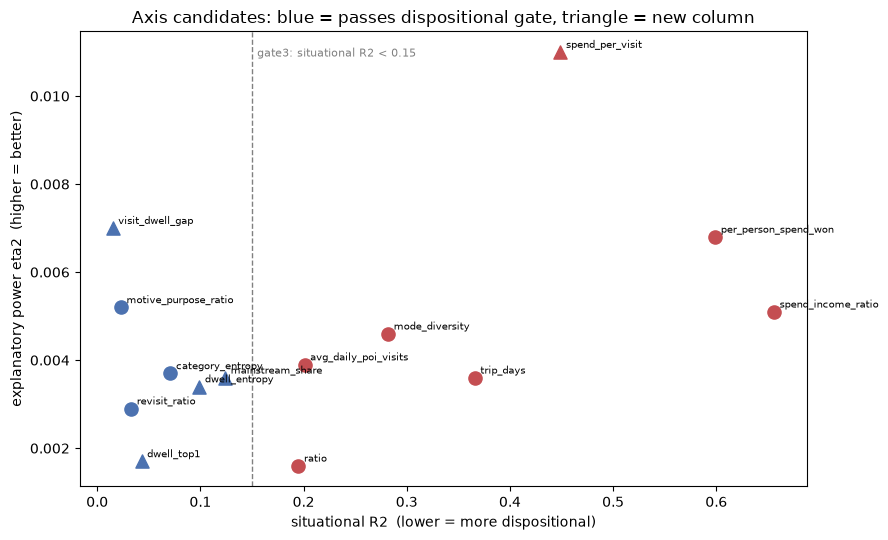

In [8]:
fig, ax = plt.subplots(figsize=(9, 5.5))
for _, r in SC.iterrows():
    ok = r['성향축'] == 'O'
    ax.scatter(r['상황R2'], r['설명력'], s=90, c='#4C72B0' if ok else '#C44E52',
               marker='o' if r['신규'] == '' else '^', zorder=3)
    ax.annotate({v: k for k, v in KR.items()}[r['축']], (r['상황R2'], r['설명력']),
                fontsize=7.5, xytext=(4, 3), textcoords='offset points')
ax.axvline(0.15, ls='--', c='gray', lw=1)
ax.text(0.155, ax.get_ylim()[1]*0.95, 'gate3: situational R2 < 0.15', fontsize=8, color='gray')
ax.set_xlabel('situational R2  (lower = more dispositional)')
ax.set_ylabel('explanatory power eta2  (higher = better)')
ax.set_title('Axis candidates: blue = passes dispositional gate, triangle = new column')
plt.tight_layout(); plt.show()

**읽는 법**: 왼쪽 위로 갈수록 좋은 축(성향적이면서 설명력 높음).

- **지출·기간·이동 계열이 전부 오른쪽(상황변수)** 이다. 소비/소득은 R²=0.66으로 사실상 **소득의 재발견**이다.
  v1 §5의 *"저효율_과소비 그룹"* 은 실제로 소득이 낮은 집단이었다(소득 205만 vs 339만).
- **v2가 채택했던 3축 중 `소비/소득`이 여기서 탈락**한다.
- 신규 컬럼 `방문↔체류불일치`가 **상황R² 0.015로 가장 순수**하면서 설명력도 상위다.

---
## 5. 전체 탐색 — 세 기준을 모두 적용해 가능한 설계를 전수 비교

축 개수 2~4개, 축별 레벨 2~4단계, 총 유형 수 4·6·8·9·12·16·18 — **모든 조합**을 만든다.
유형별 인원이 균등할 필요는 없고(최소 100명만 보장), 축별 레벨 수도 서로 달라도 된다.

In [9]:
LEV = {(c, m): np.digitize(d[c].values, np.quantile(d[c], np.arange(1, m)/m))
       for c in POOL for m in (2, 3, 4)}
SP = {}
for a, b in itertools.combinations(POOL, 2):
    v = abs(spearmanr(d[a], d[b]).correlation); SP[(a, b)] = v; SP[(b, a)] = v

def search(pool, gate_r=0.30, min_cell=100):
    out = []
    for size in (2, 3, 4):
        for combo in itertools.combinations(pool, size):
            mxr = max(SP[(a, b)] for a, b in itertools.combinations(combo, 2))
            if mxr >= gate_r: continue
            for lv in itertools.product((2, 3, 4), repeat=size):
                k = int(np.prod(lv))
                if k not in CELLS: continue
                code = np.zeros(n, dtype=np.int64)
                for c, m in zip(combo, lv): code = code*m + LEV[(c, m)]
                e2, cnt = eta2_of(code, k)
                if cnt.min() < min_cell: continue
                out.append(dict(cols=combo, lv=lv, k=k, minc=int(cnt.min()), maxr=round(mxr, 3),
                                eta2=e2, pct=e2/ceil[k]*100, nu=round(max(NUIS[c] for c in combo), 3)))
    return pd.DataFrame(out)

STYLE = [c for c in POOL if NUIS[c] < 0.15]          # ③ 성향 게이트 통과 축만
R_all   = search(POOL)                                # ① + ② 만
R_style = search(STYLE)                               # ① + ② + ③
print(f'①독립 + ②설명력 만 적용 : {len(R_all):5d}개 설계')
print(f'①+②+③성향성 모두 적용   : {len(R_style):5d}개 설계')
print(f'\n③ 통과 축 {len(STYLE)}개: ' + ', '.join(f'{KR[c]}({NUIS[c]:.2f})' for c in STYLE))
print(f'③ 탈락 축 {len(POOL)-len(STYLE)}개: ' + ', '.join(f'{KR[c]}({NUIS[c]:.2f})' for c in POOL if c not in STYLE))

①독립 + ②설명력 만 적용 :  2141개 설계
①+②+③성향성 모두 적용   :   187개 설계

③ 통과 축 7개: 목적형동기(0.02), 방문다양성(0.07), 재방문(0.03), 방문↔체류불일치(0.01), 체류다양성(0.10), 체류쏠림(0.04), 주류코스비중(0.12)
③ 탈락 축 7개: 효율성(최적동선)(0.20), 소비/소득(0.66), 방문밀도(0.20), 이동수단다양(0.28), 여행일수(0.37), 1인지출(0.60), 장소당지출(0.45)


In [10]:
def top_table(R, title, per_k=2):
    print('='*104); print(title); print('='*104)
    for k in CELLS:
        T = R[R.k == k].sort_values('pct', ascending=False)
        for _, r in T.head(per_k).iterrows():
            ax = ' × '.join(f'{KR[c]}({l})' for c, l in zip(r.cols, r.lv))
            print(f'  {r.k:2d}유형 | {ax:56s} eta² {r.eta2:.4f} = 천장의 {r.pct:4.1f}% | 최소셀 {r.minc:4d} | max|r| {r.maxr}')

top_table(R_style, '▶ 세 기준 모두 통과 — 유형 수별 최상위 (최종 후보)')

cur = R_all[(R_all.cols == ('spend_income_ratio','motive_purpose_ratio','category_entropy')) & (R_all.lv == (2,2,3))]
print('\n' + '='*104)
if len(cur):
    r = cur.iloc[0]
    rk = int((R_all[R_all.k == 12].pct > r.pct).sum()) + 1
    print(f'참고 | v2 현재 채택안(소비/소득·목적형동기·방문다양성, 2×2×3):')
    print(f'       eta² {r.eta2:.4f} = 천장의 {r.pct:.1f}%  →  ①+②기준 12유형 설계 {(R_all.k==12).sum()}개 중 {rk}위')
print(f'       ③ 성향성 게이트에서는 탈락 (소비/소득 상황R² = {NUIS["spend_income_ratio"]:.3f})')

▶ 세 기준 모두 통과 — 유형 수별 최상위 (최종 후보)
   4유형 | 목적형동기(2) × 방문↔체류불일치(2)                                   eta² 0.0087 = 천장의  3.8% | 최소셀 1168 | max|r| 0.13
   4유형 | 방문↔체류불일치(2) × 주류코스비중(2)                                  eta² 0.0083 = 천장의  3.6% | 최소셀 1134 | max|r| 0.221
   6유형 | 목적형동기(2) × 방문↔체류불일치(3)                                   eta² 0.0108 = 천장의  3.0% | 최소셀  774 | max|r| 0.13
   6유형 | 방문↔체류불일치(3) × 주류코스비중(2)                                  eta² 0.0107 = 천장의  2.9% | 최소셀  706 | max|r| 0.221
   8유형 | 목적형동기(2) × 방문↔체류불일치(4)                                   eta² 0.0125 = 천장의  2.5% | 최소셀  570 | max|r| 0.13
   8유형 | 목적형동기(2) × 방문↔체류불일치(2) × 주류코스비중(2)                       eta² 0.0123 = 천장의  2.5% | 최소셀  514 | max|r| 0.221
   9유형 | 방문↔체류불일치(3) × 주류코스비중(3)                                  eta² 0.0126 = 천장의  2.3% | 최소셀  424 | max|r| 0.221
   9유형 | 목적형동기(3) × 방문↔체류불일치(3)                                   eta² 0.0126 = 천장의  2.3% | 최소셀  499 | max|r| 0.13
  12유형 | 목적형동기(2) × 방문↔체류불일치(3) × 주류코스비중(2)

### 5-1. 기준을 하나씩 더할 때 무엇이 바뀌는가 — 대가는 정직하게

In [11]:
print(f'{"적용 기준":26s} {"4유형 최상위 설계":44s} {"천장대비":>7s}')
print('-'*82)
print(f'{"① 독립성만 (v2 방식)":24s} {"— 통과 후보들이 정의상 등가라 순위 없음":42s} {"—":>7s}')
for lbl, R in [('① + ② 설명력', R_all), ('① + ② + ③ 성향성', R_style)]:
    r = R[R.k == 4].sort_values('pct', ascending=False).iloc[0]
    ax = ' × '.join(f'{KR[c]}({l})' for c, l in zip(r.cols, r.lv))
    print(f'{lbl:24s} {ax:42s} {r.pct:6.1f}%')

적용 기준                      4유형 최상위 설계                                      천장대비
----------------------------------------------------------------------------------
① 독립성만 (v2 방식)           — 통과 후보들이 정의상 등가라 순위 없음                          —
① + ② 설명력                방문↔체류불일치(2) × 장소당지출(2)                        6.7%
① + ② + ③ 성향성            목적형동기(2) × 방문↔체류불일치(2)                        3.8%


**③을 넣으면 설명력이 절반 가까이 날아간다.** 여행 내용을 가장 잘 가르는 변수가 하필 지출·기간 계열,
즉 상황변수였기 때문이다. 그래도 이 대가를 치르는 게 맞다 — "우리 유형은 사실 소득 구간이었다"가 되면
유형 자체가 무의미해진다.

그리고 이것 자체가 **데이터에 대한 발견**이다:
> **여행에서 실제로 한 일의 상당 부분은 성향이 아니라 형편과 조건이 결정한다.**

---
## 6. 최종 설계 — 3축 8유형

세 기준을 모두 통과한 설계 중, **MBTI식 3축 이진 구조 + 최소 셀 500명 이상**을 만족하는 것으로 채택한다.

| 축 | 컬럼 | 뜻 | 상황R² |
|---|---|---|---|
| **왜 갔나** | `motive_purpose_ratio` | 목적형 ↔ 편의형 | 0.023 |
| **어떻게 다녔나** | `visit_dwell_gap` | 방문한 곳과 머문 곳이 일치 ↔ 불일치 | 0.015 |
| **어디를 갔나** | `mainstream_share` | 표준 관광코스 ↔ 비주류 취향 | 0.124 |

**대안(2축 4유형)**: `목적형동기 × 방문↔체류불일치` — 설명력 효율이 가장 높고(천장의 3.8%)
두 축 모두 상황R² 0.02 이하로 가장 순수하다. `주류코스비중`의 조성 파생 논란을 피하고 싶다면 이쪽.

In [12]:
AXES = ['motive_purpose_ratio', 'visit_dwell_gap', 'mainstream_share']
N_LEVELS = [2, 2, 2]
SHORT = {'motive_purpose_ratio':'동기', 'visit_dwell_gap':'동선', 'mainstream_share':'취향'}
LABELS = {'motive_purpose_ratio':  ['편의형','목적형'],
          'visit_dwell_gap':       ['몰입형','순회형'],     # 잠정 — 아래 프로파일로 확정할 것
          'mainstream_share':      ['탐험형','표준형']}

t = d.copy()
for ax, m in zip(AXES, N_LEVELS):
    t[SHORT[ax]] = pd.qcut(t[ax], m, labels=LABELS[ax])
t['여행유형'] = t[[SHORT[a] for a in AXES]].astype(str).agg('·'.join, axis=1)

code = np.zeros(n, dtype=np.int64)
for ax, m in zip(AXES, N_LEVELS): code = code*m + LEV[(ax, m)]
e2, cnt = eta2_of(code, int(np.prod(N_LEVELS)))
print(f'최종 설계: {" × ".join(f"{SHORT[a]}({m})" for a, m in zip(AXES, N_LEVELS))} = {int(np.prod(N_LEVELS))}유형')
print(f'  설명력 eta² = {e2:.4f}  (천장의 {e2/ceil[8]*100:.1f}%)')
print(f'  축 간 max|r| = {max(SP[(a,b)] for a,b in itertools.combinations(AXES,2)):.3f}')
print(f'  최소 셀 {cnt.min()}명 / 최대 {cnt.max()}명\n')
print(t['여행유형'].value_counts().to_string())

최종 설계: 동기(2) × 동선(2) × 취향(2) = 8유형
  설명력 eta² = 0.0123  (천장의 2.5%)
  축 간 max|r| = 0.221
  최소 셀 514명 / 최대 900명

여행유형
편의형·순회형·탐험형    1002
목적형·몰입형·표준형     786
편의형·몰입형·표준형     756
편의형·순회형·표준형     644
편의형·몰입형·탐험형     612
목적형·순회형·탐험형     558
목적형·몰입형·탐험형     534
목적형·순회형·표준형     484


In [13]:
print('━━ 축 레벨별 외부 변수 평균 (축 정의에 쓰지 않은 변수) ━━')
ext = ['income_won','trip_days','per_person_spend_won','avg_daily_poi_visits','revisit_ratio','category_entropy']
for ax in AXES:
    g = t.groupby(SHORT[ax], observed=True)[ext].mean().round(2).reindex(LABELS[ax])
    print(f'\n[{SHORT[ax]}] {KR[ax]}'); print(g.to_string())

━━ 축 레벨별 외부 변수 평균 (축 정의에 쓰지 않은 변수) ━━

[동기] 목적형동기
     income_won  trip_days  per_person_spend_won  avg_daily_poi_visits  revisit_ratio  category_entropy
동기                                                                                                     
편의형  2729761.11       3.18             228079.90                  5.08           0.27              1.28
목적형  2701947.50       3.24             242715.65                  4.92           0.11              1.26

[동선] 방문↔체류불일치
     income_won  trip_days  per_person_spend_won  avg_daily_poi_visits  revisit_ratio  category_entropy
동선                                                                                                     
몰입형  2747581.85       3.23             239695.43                  4.97           0.19              1.20
순회형  2687500.00       3.18             229325.10                  5.06           0.21              1.34

[취향] 주류코스비중
     income_won  trip_days  per_person_spend_won  avg_daily_poi_visits  revisit_ratio  cat

In [14]:
# 각 유형이 '어떤 여행'인지 — 타깃(방문 카테고리 구성)에서 전체 평균 대비 두드러진 항목
share = d[CAT].fillna(0); share = share.div(share.sum(1).clip(lower=1e-9), axis=0)
overall = share.mean()
print('━━ 유형별 특징: 전체 평균 대비 방문 비중이 높은 카테고리 상위 3개 ━━\n')
for ty, idx in t.groupby('여행유형').groups.items():
    lift = (share.loc[idx].mean()/overall.clip(lower=1e-9)).sort_values(ascending=False)
    top = ', '.join(f'{c.replace("category_share_","cat")}(x{v:.2f})' for c, v in lift.head(3).items())
    print(f'{ty:20s} n={len(idx):4d} | {top}')

━━ 유형별 특징: 전체 평균 대비 방문 비중이 높은 카테고리 상위 3개 ━━

목적형·몰입형·탐험형          n= 534 | cat2(x1.98), cat13(x1.43), cat3(x1.40)
목적형·몰입형·표준형          n= 786 | cat1(x1.58), cat11(x1.26), cat13(x0.83)
목적형·순회형·탐험형          n= 558 | cat6(x1.72), cat2(x1.71), cat8(x1.59)
목적형·순회형·표준형          n= 484 | cat1(x1.44), cat11(x1.20), cat5(x1.02)
편의형·몰입형·탐험형          n= 612 | cat4(x1.54), cat2(x1.48), cat7(x1.45)
편의형·몰입형·표준형          n= 756 | cat1(x1.50), cat11(x1.25), cat7(x0.75)
편의형·순회형·탐험형          n=1002 | cat12(x1.85), cat10(x1.74), cat8(x1.69)
편의형·순회형·표준형          n= 644 | cat1(x1.31), cat11(x1.21), cat5(x1.09)


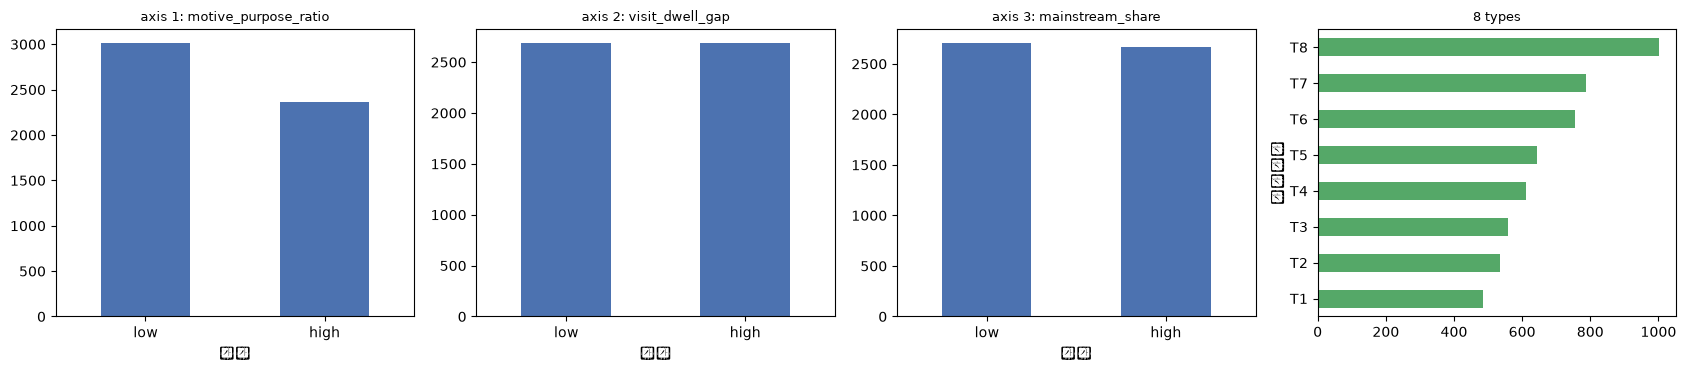

In [15]:
fig, axes = plt.subplots(1, 4, figsize=(17, 3.8))
for i, ax in enumerate(AXES):
    t[SHORT[ax]].value_counts().reindex(LABELS[ax]).plot.bar(ax=axes[i], color='#4C72B0', rot=0)
    axes[i].set_title(f'axis {i+1}: {ax}', fontsize=9); axes[i].set_xticklabels(['low','high'])
t['여행유형'].value_counts().sort_values().plot.barh(ax=axes[3], color='#55A868')
axes[3].set_title('8 types', fontsize=9); axes[3].set_yticklabels([f'T{i+1}' for i in range(8)])
plt.tight_layout(); plt.show()

⚠️ **축 레벨 이름은 잠정이다.** 위 프로파일 출력을 보고 방향을 확인한 뒤 확정할 것.
v1 §5에서 `저효율_과소비`라고 이름 붙인 그룹이 실제로는 **저소득층**이었던 실수를 반복하지 않기 위해서다.

---
## 7. Q4 — 자기보고(mission·travel_style)로 검증하면 되지 않나

**시도했고, 안 된다.** `clustering_v2.ipynb` §2-1에서 게이트 통과 22개 조합 전부를 자기보고로 채점한 결과:

| 지표 | 범위 | 판정 |
|---|---|---|
| 성향 `TRAVEL_STYL_1~8` 과의 eta² | 0.0045 ~ 0.0101 | 전부 Cohen "작은 효과"(0.01) 미만 |
| 미션 `TRAVEL_MISSION` 과의 Cramér's V | 0.0663 ~ 0.0999 | 전부 "작음"(0.1) 미만 |

**22개 조합이 자기보고와 사실상 동등하게 무관**하므로, 이걸로 순위를 매기는 것은 *노이즈로 축을 고르는* 셈이다.
PCA·AutoEncoder로 미션 공간 자체를 군집화하려는 시도도 실패했는데, 이는 방법 문제가 아니다 —
21차원 희소 multi-hot 이진 공간에는 애초에 군집이 없고, PCA는 이진 데이터에서 주변확률만 뽑아낸다.

그리고 논리적으로도 어긋난다: **"자기보고와 가장 잘 맞는 축" = "설문과 가장 겹치는 축"** 이라,
*설문이 못 잡는 행동 구조를 찾자*는 애초 목적과 정반대다.

**→ 자기보고는 선택 기준이 아니라, 유형이 설문의 재탕이 아니라는 외부 검증(say-do gap)으로 쓴다.**

---
## 8. Q5 — 최적동선 지표 `ratio`는 축으로 쓸 수 있는가

v1은 `ratio`(실제 동선 / 최적 동선)를 축A의 핵심 재료로 썼다. 검토 결과 **쓸 수 없다.**

In [16]:
r_all = RAW.dropna(subset=['ratio'])
print(f'ratio 결측 아닌 행 {len(r_all)} / 전체 {len(RAW)}')
print(f'ratio < 1 인 행: {(r_all.ratio < 1).sum()}건   ratio == 1.0 정확히: {(r_all.ratio == 1).mean():.1%}')
print(f'분석 필터(n_middle_visits>=3) 적용 후에도 ratio == 1.0 인 비율: {(d.ratio == 1.0).mean():.1%}')
print(f'spearman(ratio, n_middle_visits) = {spearmanr(r_all.ratio, r_all.n_middle_visits).correlation:+.3f}\n')

g = r_all.groupby('n_middle_visits').agg(n=('ratio','size'),
                                         p_ratio1=('ratio', lambda s: (s == 1).mean()),
                                         mean_ratio=('ratio','mean'))
print('방문지 수별 — "동선이 정확히 최적"인 비율과 평균 ratio:')
print(g.head(10).round(3).to_string())

oh = pd.get_dummies(r_all.n_middle_visits.clip(upper=15)).astype(float)
print(f'\n→ 방문지 수(계단함수)만으로 ratio를 설명한 R² = {LinearRegression().fit(oh, r_all.ratio).score(oh, r_all.ratio):.3f}')
print(f'   n_middle_visits>=5 로 조이면 ratio==1 비율 {(RAW[RAW.n_middle_visits>=5].ratio==1).mean():.1%}, '
      f'>=8 이면 {(RAW[RAW.n_middle_visits>=8].ratio==1).mean():.1%}')

ratio 결측 아닌 행 7670 / 전체 10028
ratio < 1 인 행: 0건   ratio == 1.0 정확히: 34.9%
분석 필터(n_middle_visits>=3) 적용 후에도 ratio == 1.0 인 비율: 20.6%
spearman(ratio, n_middle_visits) = +0.743

방문지 수별 — "동선이 정확히 최적"인 비율과 평균 ratio:
                    n  p_ratio1  mean_ratio
n_middle_visits                            
2                1396     1.000       1.000
3                1112     0.665       1.099
4                 922     0.359       1.182
5                 717     0.191       1.266
6                 633     0.077       1.329
7                 517     0.035       1.366
8                 417     0.014       1.458
9                 336     0.003       1.491
10                251     0.004       1.474
11                253     0.004       1.528

→ 방문지 수(계단함수)만으로 ratio를 설명한 R² = 0.339


   n_middle_visits>=5 로 조이면 ratio==1 비율 5.0%, >=8 이면 0.4%


In [17]:
# 방문지 수 효과를 층화 제거하면(그룹 내 백분위) 무엇이 남는가?
t2 = d.copy()
t2['ratio_resid'] = t2.groupby('n_middle_visits').ratio.rank(pct=True)
print(f'층화 후 spearman(ratio_resid, n_middle_visits) = {spearmanr(t2.ratio_resid, t2.n_middle_visits).correlation:+.3f}  (교란 제거됨)\n')
for c, lbl in [('ratio','원본 ratio'), ('ratio_resid','방문지수 층화 후')]:
    y = rankdata(t2[c])/len(t2)
    lab = np.digitize(t2[c].values, np.quantile(t2[c], [1/3, 2/3]))
    nl = np.mean([eta2_of(np.digitize(np.random.default_rng(s).permutation(t2[c].values),
                                      np.quantile(t2[c], [1/3, 2/3])), 3)[0] for s in range(5)])
    print(f'{lbl:16s} 상황R² = {LinearRegression().fit(Xn, y).score(Xn, y):.3f}   '
          f'설명력 eta² = {eta2_of(lab, 3)[0]:.4f}  (셔플 귀무 {nl:.4f})')

층화 후 spearman(ratio_resid, n_middle_visits) = +0.013  (교란 제거됨)



원본 ratio         상황R² = 0.195   설명력 eta² = 0.0016  (셔플 귀무 0.0004)
방문지수 층화 후        상황R² = 0.008   설명력 eta² = 0.0005  (셔플 귀무 0.0004)


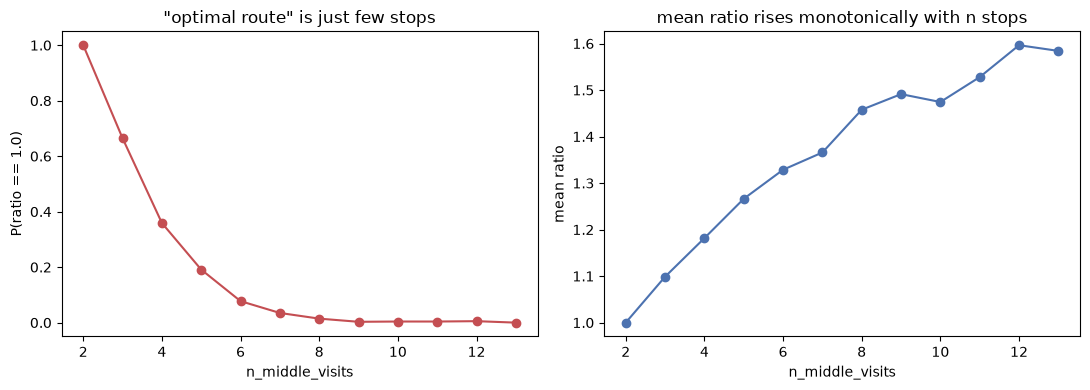

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(g.index[:12], g.p_ratio1.values[:12], 'o-', color='#C44E52')
axes[0].set_xlabel('n_middle_visits'); axes[0].set_ylabel('P(ratio == 1.0)')
axes[0].set_title('"optimal route" is just few stops')
axes[1].plot(g.index[:12], g.mean_ratio.values[:12], 'o-', color='#4C72B0')
axes[1].set_xlabel('n_middle_visits'); axes[1].set_ylabel('mean ratio')
axes[1].set_title('mean ratio rises monotonically with n stops')
plt.tight_layout(); plt.show()

### `ratio` 판정: 축으로 쓸 수 없다

1. **조합론적 교란.** 방문지가 2곳이면 100%, 3곳이면 66.5%가 "정확히 최적 동선"이다.
   8곳이면 1.4%로 떨어진다. 평균 ratio도 방문지 수를 따라 1.00 → 1.53으로 단조 증가한다.
   **방문지 수 계단함수만으로 ratio의 R² = 0.34**, spearman = **+0.74**.
   즉 `ratio`는 *동선 효율*이 아니라 **거의 방문지 개수 지표**다.
2. **점질량 아티팩트.** 필터 후에도 20.6%가 정확히 1.0에 몰려 있고,
   §2에서 본 대로 **v1 축A의 k=2 클러스터를 만든 것이 바로 이 점질량**이다.
3. **교란을 제거하면 남는 게 없다.** 방문지 수 내부 백분위로 층화하면 상황R²는 0.195 → 0.008로 깨끗해지지만,
   설명력이 0.0016 → 0.0005로 **셔플 귀무값 수준까지 떨어진다.**

> **결론: 순수한 동선 효율 성분은 여행 내용을 전혀 설명하지 못한다.
> v1 축A의 "효율성"은 사실상 방문지 개수 축이었다.**

(부수 확인: `optimal_path_is_exact = False`인 184건은 최적경로가 근사해라 ratio가 부풀려져 있다(평균 1.77 vs 1.34).
`ratio`를 어떤 형태로든 쓴다면 이 행들은 제외해야 한다.)

---
## 9. 한계 — 발표에서 주장할 수 있는 것과 없는 것

**어떤 격자 설계도 천장의 7%를 넘지 못한다.** 이것은 설계 실패가 아니라 §2에서 검증한
**"군집이 없다"의 필연적 귀결**이다. 연속체를 직교 격자로 자르면, 공간을 자유롭게 카빙하는 KMeans를 따라갈 수 없다.

| | 주장 |
|---|---|
| ❌ | "데이터에서 여행객 군집을 발견했다" |
| ❌ | "우리 유형은 여행 내용을 잘 설명한다" |
| ❌ | "이 사람은 O형이다" (개인 단위 확정 라벨 — v1 §12: 25~39%가 경계 구간) |
| ✅ | **"군집은 존재하지 않는다. 이것을 귀무분포 대비 검증으로 확인했다"** |
| ✅ | **"따라서 유형은 발견된 군집이 아니라 설계된 좌표계다"** |
| ✅ | **"세 기준(독립성·설명력·성향성)을 모두 통과한 대안 중 설명력 최상위 설계다"** |
| ✅ | **"여행에서 한 일의 상당 부분은 성향이 아니라 형편·조건이 결정한다"** |
| ✅ | "이 사람은 O형에 N% 가깝다" (정도로 표현) |

### 이 분석이 남긴 방법론적 교훈 4가지

1. **1D뿐 아니라 2D 이상에서도 실루엣은 귀무 대비로만 읽어야 한다.** (v1 §2-1의 논증을 자기 자신에게 적용)
2. **게이트로 걸러낸 지표로 다시 순위를 매기면 안 된다.** 통과자들은 정의상 그 지표에서 등가다.
3. **조성(share/비중) 데이터의 폐쇄성** — 한 항목이 크면 나머지가 기계적으로 작아진다 (§4-2, 설명력 6배 부풀림).
4. **조합론적 교란** — `ratio`처럼 표본 크기에 따라 값의 범위가 달라지는 지표는 층화해서 봐야 한다 (§8).

In [19]:
OUT = 'outputs/tables'
import os; os.makedirs(OUT, exist_ok=True)
cols = ['travel_id','traveler_id','권역'] + [SHORT[a] for a in AXES] + ['여행유형']
t[cols].to_csv(f'{OUT}/travel_types_final.csv', index=False, encoding='utf-8-sig')
SC.to_csv(f'{OUT}/axis_scorecard.csv', index=False, encoding='utf-8-sig')
R_style.assign(cols=R_style.cols.map(lambda x: ' + '.join(x)),
               lv=R_style.lv.map(lambda x: '×'.join(map(str, x)))) \
       .sort_values('pct', ascending=False) \
       .to_csv(f'{OUT}/design_search_results.csv', index=False, encoding='utf-8-sig')
print(f'저장 완료 → {OUT}/')
print('  travel_types_final.csv     유형 라벨')
print('  axis_scorecard.csv         축 후보 3기준 스코어카드')
print('  design_search_results.csv  세 기준 통과 설계 전체 순위')

저장 완료 → outputs/tables/
  travel_types_final.csv     유형 라벨
  axis_scorecard.csv         축 후보 3기준 스코어카드
  design_search_results.csv  세 기준 통과 설계 전체 순위
